### CIFAR-100
- 캐나다 고등연구원에서 만든 데이터셋
- 100개 클래스 총 60000장 (클래스당 600장)
- 이미지 크기 32*32
- CIFAR-10의 업그레이드 버전
- 데이터 증강 , 전이 학습

In [35]:
import os
import pathlib
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import datasets
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator as imgen
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten , Dropout,BatchNormalization , GlobalAveragePooling2D

In [36]:
img_size = (32,32)
batch_size = 64
num_classes = 100
class_name = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver',
    'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly',
    'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach',
    'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox',
    'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard',
    'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum',
    'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe',
    'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

In [37]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')
# 슈퍼 클래스는 label_mode=ca

In [38]:
print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


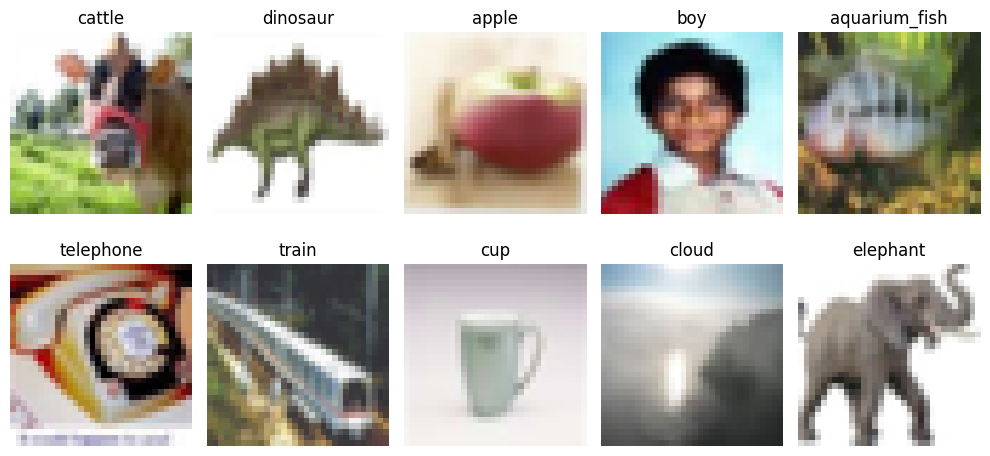

In [39]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_name[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [40]:
# 학습용 데이터 : 데이터 증강 , 정규화
train_aug = imgen(rescale=1/255,
                         horizontal_flip = True,
                         rotation_range=15, 
                         width_shift_range=0.1,
                         height_shift_range=0.1,
                         zoom_range=0.1) # 전체 중 20%를 검증용으로 분

# 검증용 데이터 : 정규화
valid_aug= imgen(rescale=1/255)

In [41]:
train_gen = train_aug.flow(
    X_train,y_train,
    batch_size = batch_size,
    shuffle=True,
    seed=123
)

test_gen = valid_aug.flow(
    X_test,y_test,
    batch_size=batch_size,
    seed=123
)

In [42]:
model_01 = Sequential()

model_01.add(Conv2D(32,3,padding='same',activation='relu',input_shape=(32,32,3)))

model_01.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model_01.add(BatchNormalization())
model_01.add(MaxPooling2D(2,2))
model_01.add(Dropout(0.25))

model_01.add(Conv2D(128,(3,3),padding='same',activation='relu'))
model_01.add(BatchNormalization())
model_01.add(MaxPooling2D(2,2))
model_01.add(Dropout(0.25))

model_01.add(Conv2D(256,(3,3),padding='same',activation='relu'))
model_01.add(BatchNormalization())
model_01.add(MaxPooling2D(2,2))
model_01.add(Dropout(0.25))

model_01.add(GlobalAveragePooling2D())
model_01.add(Dense(512,activation='relu'))
model_01.add(Dropout(0.5))

model_01.add(Dense(num_classes , activation='softmax'))

model_01.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_5 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                                 
 dropout_5 (Dropout)         (None, 16, 16, 64)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 16, 16, 128)      

In [43]:
model_01.compile(optimizer='adam' , loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

callback_01 = [EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1)]

history_01 = model_01.fit(train_gen, validation_data = test_gen, 
                   epochs=50 , callbacks = callback_01)

Epoch 1/50
782/782 [==============================] - 22s 27ms/step - loss: 3.9358 - accuracy: 0.0126 - val_loss: 3.7352 - val_accuracy: 0.0098
Epoch 2/50
782/782 [==============================] - 20s 25ms/step - loss: 3.3160 - accuracy: 0.0134 - val_loss: 3.0998 - val_accuracy: 0.0086
Epoch 3/50
782/782 [==============================] - 20s 25ms/step - loss: 2.9865 - accuracy: 0.0126 - val_loss: 3.2875 - val_accuracy: 0.0046
Epoch 4/50
782/782 [==============================] - 20s 25ms/step - loss: 2.7557 - accuracy: 0.0120 - val_loss: 2.7251 - val_accuracy: 0.0028
Epoch 5/50
782/782 [==============================] - 20s 25ms/step - loss: 2.6105 - accuracy: 0.0112 - val_loss: 2.4289 - val_accuracy: 0.0089
Epoch 6/50
782/782 [==============================] - 21s 27ms/step - loss: 2.4926 - accuracy: 0.0118 - val_loss: 2.7792 - val_accuracy: 0.0075
Epoch 7/50
782/782 [==============================] - 19s 24ms/step - loss: 2.4118 - accuracy: 0.0112 - val_loss: 2.2154 - val_accuracy:

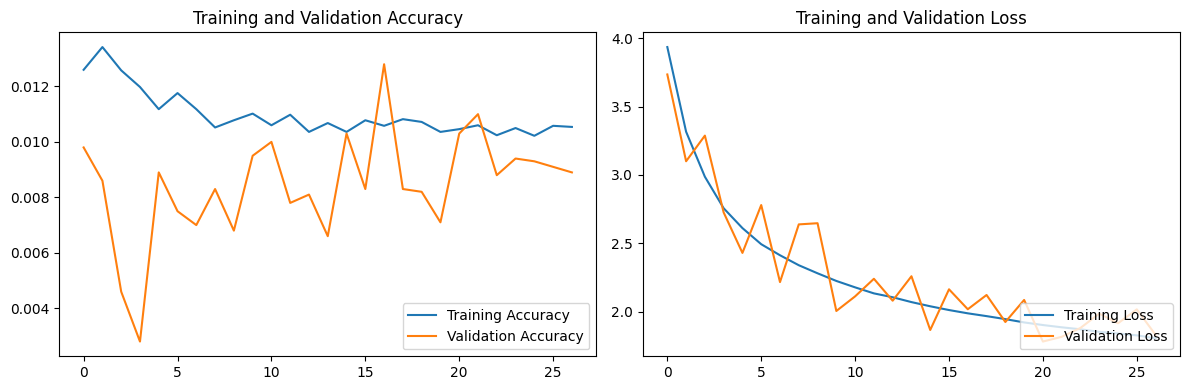

In [44]:
acc_01 = history_01.history['accuracy']
val_acc_01 = history_01.history['val_accuracy']
loss_01 = history_01.history['loss']
val_loss_01 = history_01.history['val_loss']

epochs_range_01 = np.arange(len(val_loss_01))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range_01 , acc_01 , label = 'Training Accuracy')
plt.plot(epochs_range_01 , val_acc_01 , label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_01 , loss_01 , label = 'Training Loss')
plt.plot(epochs_range_01 , val_loss_01 , label = 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [45]:
resize = 96

X_train_resized = tf.image.resize(X_train,[resize,resize]).numpy()
X_test_resized = tf.image.resize(X_test,[resize,resize]).numpy()

In [46]:
# 학습용 데이터 : 데이터 증강 , 정규화
train_aug_02 = imgen(rescale=1/255,
                  preprocessing_function = preprocess_input,
                  horizontal_flip = True,
                  rotation_range=15, 
                  width_shift_range=0.1,
                  height_shift_range=0.1,
                  zoom_range=0.1
                 ) # 전체 중 20%를 검증용으로 분

# 검증용 데이터 : 정규화
valid_aug_02 = imgen(rescale=1/255)

In [47]:
train_gen_02 = train_aug_02.flow(
    X_train,y_train,
    batch_size = batch_size,
    shuffle=True,
    seed=123
)

test_gen_02 = valid_aug_02.flow(
    X_test,y_test,
    batch_size=batch_size,
    seed=123
)

In [48]:
base_model = MobileNetV2(
    input_shape=(resize,resize,3),
    include_top = False,
    weights = 'imagenet'
)

base_model.trainable=True

for layer in base_model.layers[:30]:
    layer.trainable=False

model_02 = Sequential()

model_02.add(base_model)
model_02.add(GlobalAveragePooling2D())
model_02.add(Dense(512,activation='relu'))
model_02.add(Dropout(0.5))

model_02.add(Dense(num_classes , activation='softmax'))

model_02.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_96 (Functi  (None, 3, 3, 1280)       2257984   
 onal)                                                           
                                                                 
 global_average_pooling2d_4   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_6 (Dense)             (None, 512)               655872    
                                                                 
 dropout_9 (Dropout)         (None, 512)               0         
                                                                 
 dense_7 (Dense)             (None, 100)               51300     
                                                                 
Total params: 2,965,156
Trainable params: 2,911,508
No

In [49]:
model_02.compile(optimizer=optimizers.Adam(0.0001) , loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

callback_02 = [EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1)]

history_02 = model_02.fit(train_gen_02, validation_data = test_gen_02, 
                   epochs=50 , callbacks = callback_02)

Epoch 1/50
782/782 [==============================] - 25s 28ms/step - loss: 4.7036 - accuracy: 0.0114 - val_loss: 4.7871 - val_accuracy: 0.0022
Epoch 2/50
782/782 [==============================] - 22s 28ms/step - loss: 4.4150 - accuracy: 0.0088 - val_loss: 5.0859 - val_accuracy: 0.0028
Epoch 3/50
782/782 [==============================] - 21s 27ms/step - loss: 4.2105 - accuracy: 0.0123 - val_loss: 5.1912 - val_accuracy: 0.0015
Epoch 4/50
782/782 [==============================] - 21s 27ms/step - loss: 4.0460 - accuracy: 0.0127 - val_loss: 5.2062 - val_accuracy: 0.0185
Epoch 5/50
782/782 [==============================] - 21s 27ms/step - loss: 3.9262 - accuracy: 0.0120 - val_loss: 5.3144 - val_accuracy: 3.0000e-04
Epoch 6/50
782/782 [==============================] - 21s 27ms/step - loss: 3.8206 - accuracy: 0.0122 - val_loss: 5.4528 - val_accuracy: 1.0000e-04
Epoch 7/50
782/782 [==============================] - 21s 27ms/step - loss: 3.7367 - accuracy: 0.0108 - val_loss: 5.4575 - val_a

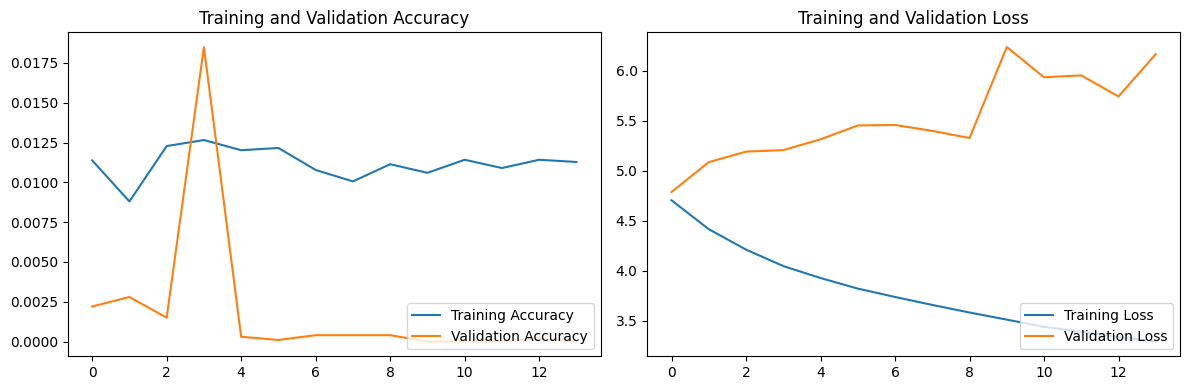

In [50]:
acc_02 = history_02.history['accuracy']
val_acc_02 = history_02.history['val_accuracy']
loss_02 = history_02.history['loss']
val_loss_02 = history_02.history['val_loss']

epochs_range_02 = np.arange(len(val_loss_02))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs_range_02 , acc_02 , label = 'Training Accuracy')
plt.plot(epochs_range_02 , val_acc_02 , label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range_02 , loss_02 , label = 'Training Loss')
plt.plot(epochs_range_02 , val_loss_02 , label = 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

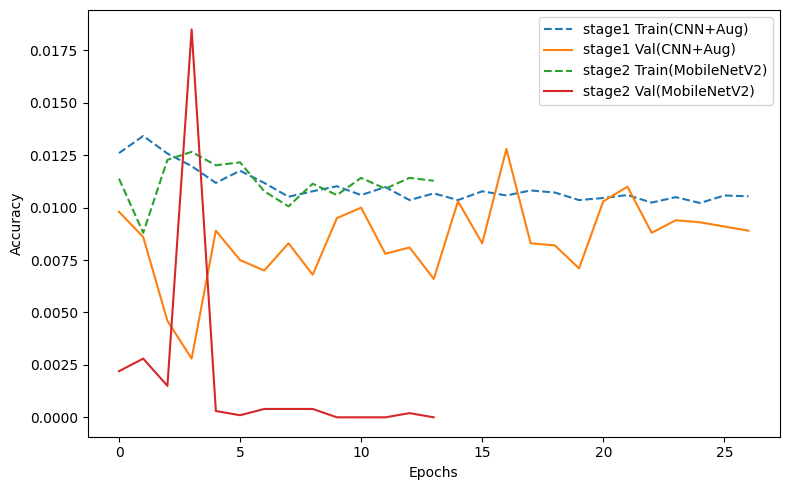

In [52]:
plt.figure(figsize=(8,5))

plt.plot(acc_01, linestyle='--', label='stage1 Train(CNN+Aug)')
plt.plot(val_acc_01, linestyle='-', label='stage1 Val(CNN+Aug)')

plt.plot(acc_02, linestyle='--', label='stage2 Train(MobileNetV2)')
plt.plot(val_acc_02, linestyle='-', label='stage2 Val(MobileNetV2)')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()